# Do Health Claim Labels Actually Mean a Food is Healthier?
### MA705, Project 2, Christie Xu
I am someone who cares about eating right. I like to look for foods with labels such as "organic," or "no preservatives." These labels are supposed to signal a healthy choice but I have always wondered if those labels are actually real and not just for marketing. 
This project analyizes whether packaged foods carrying health claim labels have a meaningful difference in their nutritional profiles compared to those without. 
This project merged two datasets from Open Foods Facts which is a crowdsourced global food label database and USDA FoodData Central a branded foods database. First I will compare key nutrients like fat, sugar, sodium, protein, and energy across the two groups, labeled and unlabeled products. 
This analysis uses descriptive statistics, visualizations, and t-tests to determine whether any observed nutrional differences are statistically meaningful. 


## Import Libraries
I will import all needed libraries before begining the project.

In [17]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

## Import Results
All libraries loaded successfully. 

## Loading First Dataset: Open Food Facts
First dataset is from Open Food Facts. We selected only columns needed for the anyalsis due to the fact this file has over 150 columns. To ensure barcodes are not treated as numbers we specify the code column as as string. We will also filter for U.S. products since the focus of this anayalsis is on the U.S. market. 

In [18]:
off = pd.read_csv('en.openfoodfacts.org.products.tsv',
                  sep='\t',
                  encoding='utf-8',
                  on_bad_lines='skip',
                  dtype={'code' : str},
                  usecols=['code', 'product_name', 'labels',
                           'sugars_100g', 'fat_100g', 'energy_100g',
                           'nutrition_grade_fr', 'countries', 'salt_100g',
                           'proteins_100g'])

off = off[off['countries'].str.contains('United States', na=False)]

print(off.shape)
off.head()

(2501, 10)


,code,product_name,labels,countries,nutrition_grade_fr,energy_100g,fat_100g,sugars_100g,proteins_100g,salt_100g
315,00005487,Sea Salt Potato Chips,NaN,United States,c,2243.0,32.14,0.00,7.14,0.95250
484,00014816,Reduced Fat Mayonnaise,NaN,United States,NaN,NaN,NaN,NaN,NaN,NaN
492,00015349,mostly mesquite honey,NaN,United States,NaN,1200.0,0.00,76.20,0.00,0.00000
496,00016063,Clam Chowder A Condensed Soup,NaN,United States,b,276.0,1.64,0.82,4.10,1.24968
585,00030991,"Pineapple, cucumber, celery, jalapeno + Kale",NaN,United States,NaN,NaN,NaN,NaN,NaN,NaN


## First Dataset Loading Results
Open Food Facts Dataset succesfully loaded and filitered with 2,501 US food products across 10 columns. Labels are clearly not available for some products which will need further investigation.

## CLearing Up Labels:
    As seen above not all products have a label filled in. First we must check for how many products have labels. Then we create a new binary column which will give a value of 1 if it has a label containing any common health or dietary keywords and return 0 if it does not. This will help us split products into two groups for comparison later. 

In [19]:
print("Products with labels:", off['labels'].notna().sum())
print("\nMost common labels:")
print(off['labels'].value_counts().head(10))

health_keywords = 'organic|gluten-free|gluten free|vegan|vegetarian|no preservatives|no gmos|natural'

off['has_health_claim'] = off['labels'].str.contains(
    health_keywords, case=False, na=False).astype(int)
print("\nHealth claim group split:")
print(off['has_health_claim'].value_counts())

Products with labels: 692

Most common labels:
labels
Kosher,Orthodox Union Kosher    44
Organic,USDA Organic            32
Gluten-free                     29
USDA Organic                    22
Orthodox Union Kosher           17
Kosher                          14
U                                9
Gluten free                      9
Organic                          9
u                                7
Name: count, dtype: int64

Health claim group split:
has_health_claim
0    2178
1     323
Name: count, dtype: int64


## Label Results
Out of the 2,501 US food products, 692 had label data filled in. After applying our key word filter, only 324 products were identified. The remaining 2,178 products do not carry any health or dietary claims. This gives us two groups to compare later on. 

## Loading Second Dataset: USDA FoodData
The second dataset comes from USDA FoodData. This comes from a very large Central Database so we will need to load and join data split across four files. 
    1. branded_food.csv
    2. food_nutrient.csv
    3. nutrient.csv
    4. food.csv
To make data consistent we will use only us products

In [20]:
branded = pd.read_csv('branded_food.csv',
                      dtype={'gtin_upc': str},
                      usecols=['fdc_id', 'gtin_upc', 'branded_food_category', 'ingredients'])
food_nutrient = pd.read_csv('food_nutrient.csv',
                            usecols=['fdc_id', 'nutrient_id', 'amount'])
nutrient = pd.read_csv('nutrient.csv',
                       usecols=['id', 'name'])
food_names = pd.read_csv('food.csv',
                          usecols=['fdc_id', 'description', 'market_country'])
print("Branded foods shape:", branded.shape)
print("Food nutrient shape:", food_nutrient.shape)
print("Nutrient lookup shape:", nutrient.shape)
print("Food names shape:", food_names.shape)

Branded foods shape: (1993975, 4)
Food nutrient shape: (25937630, 3)
Nutrient lookup shape: (477, 2)
Food names shape: (1993975, 3)


## Second Dataset Loading Results
The four files loaded. Branded foods file contains almost 2 million across 4 columns. Food nutrient contained over 25 million rows. This is very large because each nutrient for each product is stored as its own separate row. Nutrient lookup shows 477 different nutrients tracked by the USDA. Lastly Food Shape shapes over 1 million product names.

## Join Three Files Together

We must join these files before we can use it. We will do this by attaching nutrient names to the nutrition numbers, then we will filiter to only the four nutrients relevant to our anaylasis. These will be fat, energy, sodium, and protein. We also want the output to be readable so we will reshape our data so that each nutrient becomes its own column. This will give us a clean presentable layout.

In [21]:
fn_merged = food_nutrient.merge(nutrient,
                                 left_on='nutrient_id',
                                 right_on='id')

nutrients_we_need = ['Total lipid (fat)',
                     'Energy',
                     'Sodium, Na',
                     'Protein']

fn_filtered = fn_merged[fn_merged['name'].isin(nutrients_we_need)]

nutrients_wide = fn_filtered.pivot_table(index='fdc_id',
                                          columns='name',
                                          values='amount',
                                          aggfunc='mean')

usda = branded.merge(nutrients_wide, on='fdc_id')
usda = usda.merge(food_names.rename(columns={'description': 'product_name'}),
                  on='fdc_id', how='left')

usda = usda[usda['market_country'] == 'United States']

usda = usda[['fdc_id', 'gtin_upc', 'product_name',
             'branded_food_category', 'ingredients',
             'Energy', 'Protein', 'Sodium, Na',
             'Total lipid (fat)']]

print(usda.shape)
usda.head()

(1878053, 9)


,fdc_id,gtin_upc,product_name,branded_food_category,ingredients,Energy,Protein,"Sodium, Na",Total lipid (fat)
0,1105904,00027000612323,WESSON Vegetable Oil 1 GAL,Oils Edible,Vegetable Oil,867.0,0.00,0.0,93.33
1,1105905,00051000198808,SWANSON BROTH BEEF,Herbs/Spices/Extracts,"INGREDIENTS: BEEF STOCK, CONTAINS LESS THAN 2%...",4.0,0.83,346.0,0.00
2,1105906,00051000213273,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,Prepared Soups,"INGREDIENTS: CLAM STOCK, POTATOES, CLAMS, CREA...",82.0,2.45,363.0,5.31
3,1105907,00051000213303,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,Prepared Soups,"INGREDIENTS: WATER, CREAM, BROCCOLI, CELERY, V...",82.0,1.22,322.0,6.12
4,1105908,00051000224637,SWANSON BROTH CHICKEN,Herbs/Spices/Extracts,"INGREDIENTS: CHICKEN STOCK, CONTAINS LESS THAN...",4.0,0.83,15.0,0.00


## Dataset Two Results
The four files were sucessfully joined together into a single table containing 1,878,053 food products from the US across 9 columns which represents one product along with its details including barcode, product name, ingredients, food category, and government verified nutritional values for our four key varibles energy, protien, sodium, and fat. 

## Merging Datasets
Now that both datasets have been loaded and cleaned, we will merge them together using the barcode column that exists within both of these datasets. In the Open Food dataset the column we will use is 'code' and in the USDA one we will use 'gtin_upc' column. We will use an inner join which allows us to keep only products that appear within both datasets. We will also be standardizing barcodes so that products don't get cut out due to differences in formatting between the two datasets. This allows us to create a dataset that allows us to compare the health claim labels from Open Food compared to government verified nutritional values from the USDA dataset. 

In [22]:
off['code'] = off['code'].str.strip().str.zfill(14)
usda['gtin_upc'] = usda['gtin_upc'].str.strip().str.zfill(14)
merged = off.merge(usda,
                   left_on='code',
                   right_on='gtin_upc',
                   how='inner')
print("Merged dataset shape:", merged.shape)
print("\nColumns:", merged.columns.tolist())
merged.head()

Merged dataset shape: (8779, 20)

Columns: ['code', 'product_name_x', 'labels', 'countries', 'nutrition_grade_fr', 'energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g', 'has_health_claim', 'fdc_id', 'gtin_upc', 'product_name_y', 'branded_food_category', 'ingredients', 'Energy', 'Protein', 'Sodium, Na', 'Total lipid (fat)']


,code,product_name_x,labels,countries,nutrition_grade_fr,energy_100g,fat_100g,sugars_100g,proteins_100g,salt_100g,has_health_claim,fdc_id,gtin_upc,product_name_y,branded_food_category,ingredients,Energy,Protein,"Sodium, Na",Total lipid (fat)
0,00000000005487,Sea Salt Potato Chips,NaN,United States,c,2243.0,32.14,0.0,7.14,0.9525,0,359586,00000000005487,POTATO CHIPS,"Chips, Pretzels & Snacks","UNPEELED POTATOES, SUNFLOWER OIL, SEA SALT.",536.0,7.14,375.0,32.14
1,00000000005487,Sea Salt Potato Chips,NaN,United States,c,2243.0,32.14,0.0,7.14,0.9525,0,1850914,00000000005487,"POTATO CHIPS, SEA SALT","Chips, Pretzels & Snacks","UNPEELED POTATOES, SUNFLOWER OIL, SEA SALT.",536.0,7.14,375.0,32.14
2,00000000005487,Sea Salt Potato Chips,NaN,United States,c,2243.0,32.14,0.0,7.14,0.9525,0,1759872,00000000005487,"POTATO CHIPS, SEA SALT","Chips, Pretzels & Snacks","UNPEELED POTATOES, SUNFLOWER OIL, SEA SALT.",536.0,7.14,375.0,32.14
3,00000000014816,Reduced Fat Mayonnaise,NaN,United States,NaN,NaN,NaN,NaN,NaN,NaN,0,539502,00000000014816,REDUCED FAT MAYO DRESSING,Salad Dressing & Mayonnaise,"WATER, EXPELLER PRESSED CANOLA OIL, CORNSTARCH...",233.0,0.00,700.0,23.33
4,00000000014816,Reduced Fat Mayonnaise,NaN,United States,NaN,NaN,NaN,NaN,NaN,NaN,0,1333642,00000000014816,REDUCED FAT MAYO DRESSING,Salad Dressing & Mayonnaise,"WATER, EXPELLER PRESSED CANOLA OIL, CORNSTARCH...",233.0,0.00,700.0,23.33


## Merge Results
Two datasets merged correclty, there are 20 columns in this table with the nutrional data from both sources showing up side by side. Standarization of barcodes also ensured cocnsitent formatting between the datasets. There is a clear issue of duplicates with the rows and there is also two product name columns which should be kept to just one. 

## Investigating Unmatched Products
Even though the merge worked there is a significant number of the Open Food facts products that did not match in the USDA database. So I will determine how many products were lost and why before moving on.

In [23]:
unmatched = off[~off['code'].isin(usda['gtin_upc'])]
print("OFF products that did not match USDA:", len(unmatched))
print("OFF products total:", len(off))
print("Match rate:", round(len(off[off['code'].isin(usda['gtin_upc'])]) / len(off) * 100, 1), "%")

OFF products that did not match USDA: 1073
OFF products total: 2501
Match rate: 57.1 %


## Match Investigation Results
Out of 2,501 Open Food Facts products, 1073 did not find a match in the USDA database. This gives us a match rate of 57.1%. There are a few likely reasons for this. One being barcodes are entered manually by contributotrs and may contain formatting issues. Some products may only exisit in one database and not the other. These are the accepted limitations of merging two independently maintained databases.

## Checking duplicates
Before removing the duplicated rows, I first want to understand why they exisit. The code below checks how many duplicate barcodes exist and shows a sample of them.

In [24]:
dupes = merged[merged.duplicated(subset='code', keep=False)]
print("Duplicate rows:", len(dupes))
print("\nSample of duplicates:")
print(dupes[['code', 'product_name_x', 'has_health_claim']].head(10))

Duplicate rows: 8715

Sample of duplicates:
             code                 product_name_x  has_health_claim
0  00000000005487          Sea Salt Potato Chips                 0
1  00000000005487          Sea Salt Potato Chips                 0
2  00000000005487          Sea Salt Potato Chips                 0
3  00000000014816         Reduced Fat Mayonnaise                 0
4  00000000014816         Reduced Fat Mayonnaise                 0
5  00000000014816         Reduced Fat Mayonnaise                 0
6  00000000014816         Reduced Fat Mayonnaise                 0
7  00000000016063  Clam Chowder A Condensed Soup                 0
8  00000000016063  Clam Chowder A Condensed Soup                 0
9  00000000016063  Clam Chowder A Condensed Soup                 0


## Check Results
The check revealed 8,715 duplicate rows across the merged dataset. The above sample shows a clear pattern of the same product appearing multiple times under the same barcode. This most likely happens because the USDA database contains multiple entries for the same product barcode, likely due to it being updated over time or reentered. Due to the fact the product name and health claim values are identical across all the duplicate rows keeping just the first occurrence and dropping the rest does not affect the anaylsis.

## Fixing Duplicates
The issue above can be fixed by dropping duplicate barcodes and keeping just the first matach along with dropping the USDA product name while keeping Open Foods version and renaming it for simplicity. 

In [25]:
merged = merged.drop_duplicates(subset='code')

merged = merged.drop(columns=['product_name_y', 'gtin_upc'])
merged = merged.rename(columns={'product_name_x': 'product_name'})

print("Shape after deduplication:", merged.shape)
merged.head()

Shape after deduplication: (1427, 18)


,code,product_name,labels,countries,nutrition_grade_fr,energy_100g,fat_100g,sugars_100g,proteins_100g,salt_100g,has_health_claim,fdc_id,branded_food_category,ingredients,Energy,Protein,"Sodium, Na",Total lipid (fat)
0,00000000005487,Sea Salt Potato Chips,NaN,United States,c,2243.0,32.14,0.00,7.14,0.95250,0,359586,"Chips, Pretzels & Snacks","UNPEELED POTATOES, SUNFLOWER OIL, SEA SALT.",536.0,7.14,375.0,32.14
3,00000000014816,Reduced Fat Mayonnaise,NaN,United States,NaN,NaN,NaN,NaN,NaN,NaN,0,539502,Salad Dressing & Mayonnaise,"WATER, EXPELLER PRESSED CANOLA OIL, CORNSTARCH...",233.0,0.00,700.0,23.33
7,00000000016063,Clam Chowder A Condensed Soup,NaN,United States,b,276.0,1.64,0.82,4.10,1.24968,0,397546,Canned Soup,"SEA CLAMS, SEA CLAM JUICE, POTATOES, WHEAT FLO...",66.0,4.10,492.0,1.64
12,00041500007007,Yellow Mustard,NaN,United States,b,NaN,NaN,NaN,NaN,NaN,0,407369,"Ketchup, Mustard, BBQ & Cheese Sauce","DISTILLED VINEGAR, WATER, #1 GRADE MUSTARD SEE...",0.0,0.00,1100.0,0.00
20,00000000073448,21 Seasoning Salute,NaN,United States,NaN,0.0,0.00,NaN,0.00,0.00000,0,387273,"Seasoning Mixes, Salts, Marinades & Tenderizers","ONION, SPICES (BLACK PEPPER, CELERY SEED, CAYE...",0.0,0.00,0.0,0.00


## Duplicate Removal Results
After removing duplicates the merged dataset now contains one row per unique product. The table shows a sample of the cleaned data with nutritional information from both sources appearing side by side which confirms the merge worked. Some products are missing values in certain columns which will be addressed.

## Cleaning Missing Values
I will now drop any products that are missing nutritional values we need for our analysis. Dropping them because a product with no fat, sugar, sugar, or energy data cannot be meaningfully compared. 

In [26]:
merged_clean = merged.dropna(subset=['fat_100g', 'sugars_100g', 
                                      'proteins_100g', 'Energy', 
                                      'Protein', 'Sodium, Na', 
                                      'Total lipid (fat)'])

print("Shape after dropping missing nutritional values:", merged_clean.shape)
print("\nHealth claim split after cleaning:")
print(merged_clean['has_health_claim'].value_counts())

Shape after dropping missing nutritional values: (924, 18)

Health claim split after cleaning:
has_health_claim
0    796
1    128
Name: count, dtype: int64


## Cleaned Merge Results
This dataset contains 924 products after cleaning. From that list 128 carry at least one health claim label while 796 do not. 

## EDA
Before running tests. I will examine the distribution of key nutrional values across products with and without health claims. The table below will show the mean, median, and standard deviation for five nutrients: fat, sugar, protein. energy, and sodium.

In [27]:
nutrients = ['fat_100g', 'sugars_100g', 'proteins_100g',
             'Energy', 'Sodium, Na']
summary = merged_clean.groupby('has_health_claim')[nutrients].agg(['mean', 'median', 'std']).round(2)
print(summary)

                 fat_100g               sugars_100g                \
                     mean median    std        mean median    std   
has_health_claim                                                    
0                   13.72   5.58  18.16       15.88   7.14  19.64   
1                   14.84   4.32  20.83       13.28   5.48  19.23   

                 proteins_100g               Energy                Sodium, Na  \
                          mean median   std    mean median     std       mean   
has_health_claim                                                                
0                         6.74   4.60  7.42  287.81  301.0  189.88     604.59   
1                         6.75   3.96  8.02  305.82  340.5  206.76     369.43   

                                  
                 median      std  
has_health_claim                  
0                 257.0  2180.27  
1                 278.5   475.22  


## EDA Results
The table shows a pattern where products with health claims have a lower mean sodium and a lower mean sugar compared to products without claims, while fat and protein means are nearly identical across both groups. An important thing to note is the sodium standard deviation for no claim groups were larger than health claim groups which means there are extreme outliers.

## Visualization
I will create a box plot to visualize the distribution of each nutrient across the two groups. 

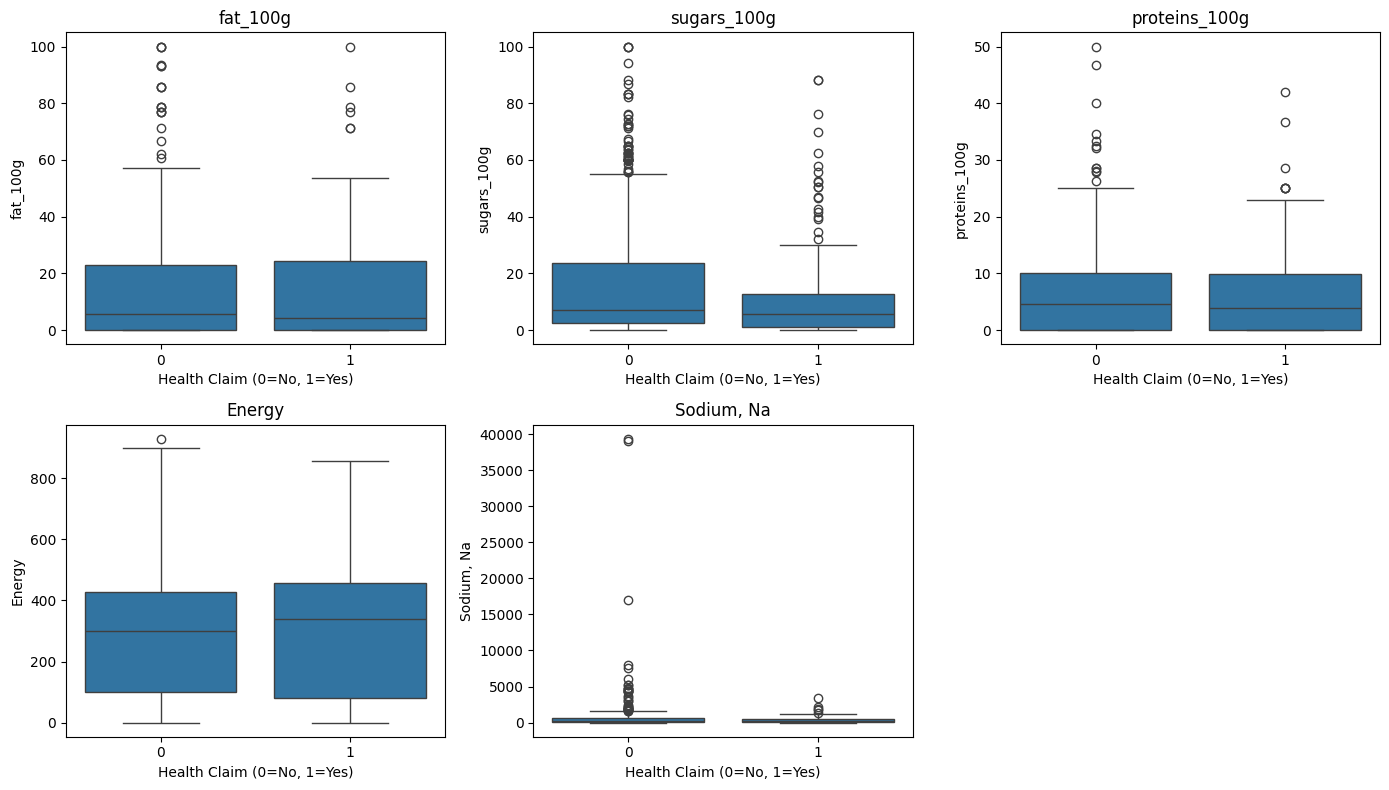

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, nutrient in enumerate(nutrients):
    sns.boxplot(data=merged_clean, x='has_health_claim', y=nutrient, ax=axes[i])
    axes[i].set_title(nutrient)
    axes[i].set_xlabel('Health Claim (0=No, 1=Yes)')
axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('boxplot.png', dpi=150)
plt.show()

## Boxplot Results
The charts show us that fat and protein levels look almost identical for both groups. Sugar is visibly lower for health claim products. The most interesting takeaway from this plot is the sodium chart which shows an extreme outlier near 40,000mg. This most likely was a data entry error. Due to this outlier the chart becomes difficult to read but also explains why the no-claim group had such a high standard deviation in the EDA results. These plots show a pattern that sodium and sugar appear to be the nutrients most assoicated with health claim labeling. 

## Hypothesis Testing (T-Tests)
To test whether nutritional differences between groups are statistically significant, I will use this teszt to compare the two groups and produce a p-value. If the value is below 0.05 the differences are considered statistically significant. Which means these patterns are unlikely to have happened by chance

In [29]:
claim = merged_clean[merged_clean['has_health_claim'] == 1]
no_claim = merged_clean[merged_clean['has_health_claim'] == 0]

for nutrient in nutrients:
    t, p = stats.ttest_ind(claim[nutrient], no_claim[nutrient], equal_var=False)
    print(f"{nutrient}: t={t:.3f}, p={p:.4f}, {'SIGNIFICANT' if p <0.05 else 'not significant'}")

fat_100g: t=0.572, p=0.5680, not significant
sugars_100g: t=-1.414, p=0.1591, not significant
proteins_100g: t=0.013, p=0.9898, not significant
Energy: t=0.925, p=0.3564, not significant
Sodium, Na: t=-2.674, p=0.0076, SIGNIFICANT


## T-Test Result
Out of the five nutrients tested only sodium came back as statistically significant. This means products with health claims had a meaningfully lower sodium level compared to products without claims. All the other four nutrients showed up as not significant which means while health claim products appeared to have slightly lower sugar on average the gap was not large enough to rule out random variation. This means health claim labels on packaged foods are associated with lower sodium levels, but not with meaningful differences in fat,sugar, protein, or energy. 

## Per-Label Analysis
The previous analysis grouped all health claim labels together into a single category. Which hides potential health differences between individual labels. To investigate this, seperate t-tests will be run for each indivudal label comparing that label's products against products with no health claims at all.

In [30]:
labels_to_test = ['organic', 'gluten-free', 'vegan', 'vegetarian', 
                  'no preservatives', 'no gmos', 'natural']

nutrients = ['fat_100g', 'sugars_100g', 'proteins_100g', 'Energy', 'Sodium, Na']

results = []

for label in labels_to_test:
    label_group = merged_clean[merged_clean['labels'].str.contains(
        label, case=False, na=False)]
    
    if len(label_group) < 5:  
        continue
        
    row = {'Label': label, 'Count': len(label_group)}
    
    for nutrient in nutrients:
        t, p = stats.ttest_ind(label_group[nutrient], no_claim[nutrient], 
                               equal_var=False)
        row[nutrient + '_p'] = round(p, 4)
        row[nutrient + '_sig'] = 'YES' if p < 0.05 else 'no'
    
    results.append(row)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

           Label  Count  fat_100g_p fat_100g_sig  sugars_100g_p sugars_100g_sig  proteins_100g_p proteins_100g_sig  Energy_p Energy_sig  Sodium, Na_p Sodium, Na_sig
         organic     61      0.4237           no         0.6876              no           0.7004                no    0.5458         no        0.0001            YES
     gluten-free     45      0.8046           no         0.5758              no           0.2769                no    0.0277        YES        0.0285            YES
           vegan     17      0.9995           no         0.7073              no           0.2558                no    0.4644         no        0.0006            YES
      vegetarian      8      0.0340          YES         0.3400              no           0.2260                no    0.4866         no        0.0045            YES
no preservatives     12      0.5427           no         0.0005             YES           0.7337                no    0.2767         no        0.8908             no
         n

## Per-Label Results
The above breakdown shows sodium was significant for most labels. Being lower for organic, gluten-free, vegan, vegetarian, no GMOs, and natural. Individual labels showed no preservatives and natural products had lower sugar, while gluten-free products had higher energy, and vegetarian products had lower fat. Suprisingly vegan products showed no significant fat difference. Protien was also not significant for any label.

## Per-Label Visualization
To make the above results easier to read a heatmap will be created to show the p-value for each label-nutrient combination. Green cells will show a statistically significant difference which will be a p-value < 0.05, between that label group and products with no claim. 

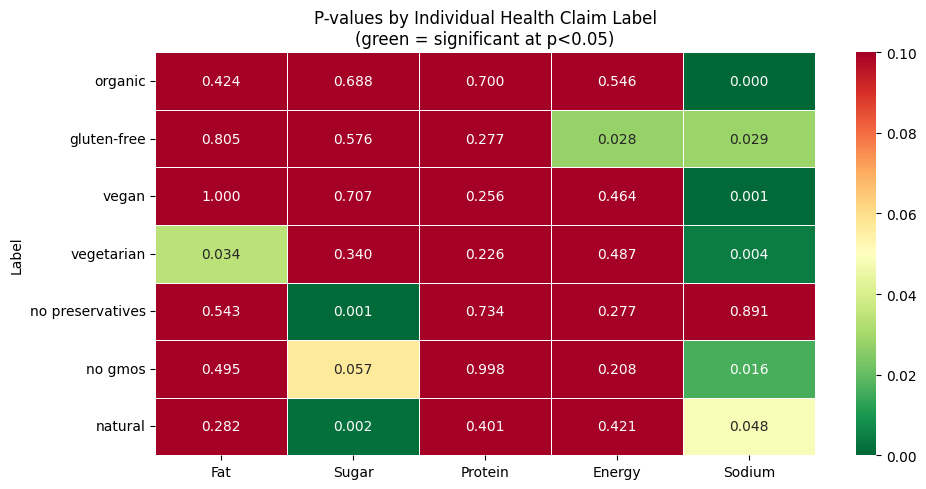

In [31]:
p_cols = [n + '_p' for n in nutrients]
nutrient_labels = ['Fat', 'Sugar', 'Protein', 'Energy', 'Sodium']

heatmap_data = results_df.set_index('Label')[p_cols]
heatmap_data.columns = nutrient_labels

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn_r',
            vmin=0, vmax=0.1, linewidths=0.5)
plt.title('P-values by Individual Health Claim Label\n(green = significant at p<0.05)')
plt.tight_layout()
plt.savefig('label_heatmap.png', dpi=150)
plt.show()

## HeatMap Results
The heatmap clarifies that sodium is the most consistently green. Showing significance for organic, gluten-free, vegan, vegetarian, no GMOs, and natural.
Sugar is only significant for no preservatives and natural. 
Energy is only green for gluten-free, while fat is only green in vegetarian and protein is entirely red across all labels.

## Per-Label Summary
Printing a summary of which nutrients were statistically significant for each indivudal label allows for easier interpretation.

In [32]:
for label in results_df['Label']:
    row = results_df[results_df['Label'] == label].iloc[0]
    sig = [n for n in nutrient_labels if 
           results_df[results_df['Label']==label][nutrients[nutrient_labels.index(n)]+'_p'].values[0] < 0.05]
    print(f"{label} (n={int(row['Count'])}): significant for {sig if sig else 'nothing'}")

organic (n=61): significant for ['Sodium']
gluten-free (n=45): significant for ['Energy', 'Sodium']
vegan (n=17): significant for ['Sodium']
vegetarian (n=8): significant for ['Fat', 'Sodium']
no preservatives (n=12): significant for ['Sugar']
no gmos (n=13): significant for ['Sodium']
natural (n=5): significant for ['Sugar', 'Sodium']


## Summary Results
This confirms our findings above. Sodium is significant for 6/7 labels, gluten-free products show higher energy, vegetarian had lower fat, no preservatives and natural both had lower sugar, and no label was significant for protein.

## Limitations
 1. The per-label sample sizes for some labels were small. Vegetarian had only 8 products and natural had only 5 which means due to small sample size results should be interpreted cautiously.
 2. Only 128 out of 924 products from the merged dataset carried any health claim labels which is roughly 14%. While it is sufficient for the t-test, larger sample sizes per label would produce more reliable per-label results.
 3. The merged dataset only represents 57.1% of the original Open Food Facts products because of barcode mismtaches. This means matched products may not fully represent all packaged foods on the market. 
 4. An extreme outlier of 40,000mg in the no-claim sodium group inflated the variance. However the t-test is designed to handle unequal variances between groups. 

## Conclusion
The final merged and cleaned dataset from Open Food Facts and USDA FoodData Central contained 924 products, 128 of which carried at least one health claim label. The analysis found sodium to be the only nutrient with a statistically significant difference. Showing a p-value of 0.0076 and averaging 369mg for health claims vs 605mg for no health claims per 100g.
The per-label analysis dove deeper and found sodium was significantly lower for organic, gluten-free, vegan, vegetarian, no GMOs, and natural. Which were 6/7 labels tested in this analysis. Gluten-free products showed higher energy, vegetarian had lower fat, no preservatives and natural both had lower sugar, and no label was significant for protein. 
A label is meaningful based on which label it is and which nutrient you care about. Consumers looking to reduce sodium will find that most health-claimed products will deliver results. However for other nutrients, reading the full nutrition label remains the most reliable. 